In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import glob
import pickle
import itertools
import numpy as np
from tqdm import tqdm

import evaluation

/gs/bs/tgh-25IAC/ud03523/TOOL/pydev/envs/jupyter/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
import matplotlib
import matplotlib.pyplot as plt

# Error per attack & language

In [66]:
# load the protocol
eval_data_path = Path('../data/protocols/eval.csv')
eval_data_list = pd.read_csv(eval_data_path, names=['data'])


# get the language label
eval_data_list['lang'] = eval_data_list['data'].apply(lambda x: x.split('_')[1])

# get the vocoder label
eval_data_list['attack'] = eval_data_list['data'].apply(lambda x: '_'.join(x.split('/')[0].split('_')[2:]))

eval_data_list.head()

,data,lang,attack
0,replacement_de_hifigan/vtt_modified/IxD9PhJ9aD...,de,hifigan
1,replacement_de_hifigan/vtt_modified/IxD9PhJ9aD...,de,hifigan
2,replacement_de_hifigan/vtt_modified/FkIcyFEbM_...,de,hifigan
3,replacement_de_hifigan/vtt_modified/6eNxVeS6Cv...,de,hifigan
4,replacement_de_hifigan/vtt_modified/hYq6KJnwPI...,de,hifigan


In [67]:
csv_save_dir = Path('project/results_csv')
csv_save_dir.mkdir(exist_ok=True)

In [6]:
hparams = ['full_x01','full_x02','full_x03','full_x04','full_x05']

for hparam in hparams:
    # load results
    sys_path = Path('project/cp_whisper_hparams_{:s}.yaml/artifacts/outputs/'.format(hparam))

    output_files = glob.glob('*.pkl', root_dir=sys_path)
    assert len(output_files)==1, "Found multiple files, choose one to analysis: {:s}".format('\n'.join(output_files))

    with open(sys_path / output_files[0], 'rb') as file_ptr:
        output_data = pickle.load(file_ptr)
    assert len(output_data) == 2, "The input is supposed to be [res, refs]"
    output_data = [np.array(output_data[0]), np.array(output_data[1])]
    
    # comptue results
    langs = sorted(eval_data_list['lang'].unique())
    attacks = sorted(eval_data_list['attack'].unique())

    metrics_all = []
    for lang, attack in itertools.product(langs, attacks):
        data_idx = eval_data_list.query('lang == "{:s}" and attack == "{:s}"'.format(lang, attack)).index
        res, refs = output_data[0][data_idx], output_data[1][data_idx]
        cer, wer, metrics = evaluation.comptue_metrics(res, refs)
        metrics['cer'] = cer * 100
        metrics['wer'] = wer * 100
        metrics['lang'] = lang
        metrics['attack'] = attack
        metrics_all.append(metrics)
        
    # save
    results = pd.DataFrame(metrics_all)
    results.to_csv(csv_save_dir / 'cp_whisper_hparams_{:s}.csv'.format(hparam))
    print(csv_save_dir / 'cp_whisper_hparams_{:s}.csv'.format(hparam))

project/results_csv/cp_whisper_hparams_full_x01.csv
project/results_csv/cp_whisper_hparams_full_x02.csv
project/results_csv/cp_whisper_hparams_full_x03.csv
project/results_csv/cp_whisper_hparams_full_x04.csv
project/results_csv/cp_whisper_hparams_full_x05.csv


In [68]:
csv_save_dir = Path('../spoofing-loc-vocoded-aug-res/project/results_csv')
csv_save_dir.mkdir(exist_ok=True)

In [71]:
hparams = ['res_full_x01']

for hparam in hparams:
    # load results
    sys_path = Path('../spoofing-loc-vocoded-aug-res/project/cp_whisper_hparams_{:s}.yaml/artifacts/outputs/'.format(hparam))

    output_files = glob.glob('*.txt.pkl', root_dir=sys_path)
    assert len(output_files)==1, "Found multiple files, choose one to analysis: {:s}".format('\n'.join(output_files))

    with open(sys_path / output_files[0], 'rb') as file_ptr:
        output_data = pickle.load(file_ptr)
        
    assert len(output_data) == 2, "The input is supposed to be [res, refs]"
    output_data = [np.array(output_data[0]), np.array(output_data[1])]
    
    # comptue results
    langs = sorted(eval_data_list['lang'].unique())
    attacks = sorted(eval_data_list['attack'].unique())

    metrics_all = []
    for lang, attack in itertools.product(langs, attacks):
        data_idx = eval_data_list.query('lang == "{:s}" and attack == "{:s}"'.format(lang, attack)).index
        res, refs = output_data[0][data_idx], output_data[1][data_idx]
        cer, wer, metrics = evaluation.comptue_metrics(res, refs)
        metrics['cer'] = cer * 100
        metrics['wer'] = wer * 100
        metrics['lang'] = lang
        metrics['attack'] = attack
        metrics_all.append(metrics)
        
    # save
    results = pd.DataFrame(metrics_all)
    results.to_csv(csv_save_dir / 'cp_whisper_hparams_{:s}.csv'.format(hparam))
    print(csv_save_dir / 'cp_whisper_hparams_{:s}.csv'.format(hparam))

../spoofing-loc-vocoded-aug-res/project/results_csv/cp_whisper_hparams_res_full_x01.csv


# Error analysis

In [42]:
def get_conf_inter(far, frr, nneg, npos, alpha=1.960):
    sigma = np.sqrt(far * (1-far) / nneg + frr * (1-frr) / npos ) / 2
    return sigma

In [4]:
error_token_file = '/gs/bs/tgh-25IAC/ud03523/WORK/project-partialspoof/spoofing-loc-vocoded-aug/project/cp_whisper_hparams_full_x01.yaml/artifacts/outputs/error_token.pkl'

with open(error_token_file, 'rb') as file_ptr:
    error_file = pickle.load(file_ptr)

In [9]:
error_file[3]

[[3565, 35889], 1, 0, 0, 0]

In [23]:
from collections import Counter
import itertools 

hist = Counter(itertools.chain(*[x[0] for x in error_file]))
hist_sum = sum(hist.values())

In [27]:
def reform(data):
    prob = np.mean([hist[x]/hist_sum for x in data[0]])
    return [prob * 100] + data[1:]
error_file_tmp = np.array([reform(x) for x in error_file])

error_file_pd = pd.DataFrame(error_file_tmp, columns=['prob', 'a', 'b', 'c', 'd'])

In [32]:
probs = sorted(error_file_pd['prob'].unique())
nbins = 10
counts, bins = np.histogram(probs, bins=nbins)

In [33]:
bins

array([8.81733135e-04, 3.39048434e-01, 6.77215134e-01, 1.01538183e+00,
       1.35354854e+00, 1.69171524e+00, 2.02988194e+00, 2.36804864e+00,
       2.70621534e+00, 3.04438204e+00, 3.38254874e+00])

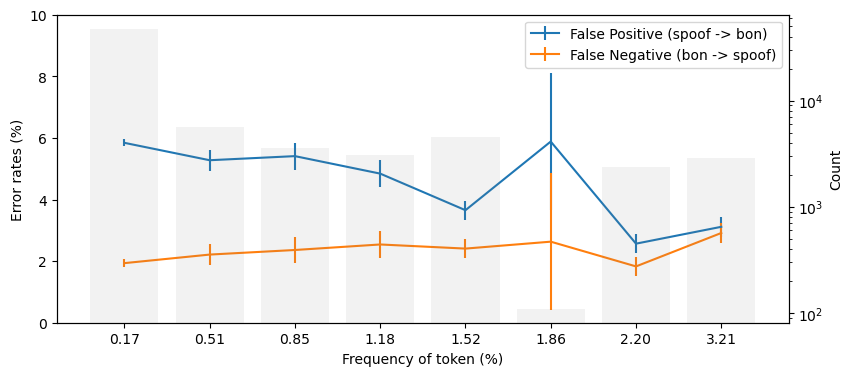

In [59]:
errors = []
for start, end in zip(bins[:-1], bins[1:]):
    data_ = error_file_pd.query('prob >= {:f} and prob < {:f}'.format(start, end))
    a = data_['a'].sum()
    b = data_['b'].sum()
    c = data_['c'].sum()
    d = data_['d'].sum()
    total = a + b + c + d
    accuracy = (a + b) / total if total > 0 else 0
    false_positive_rate = d / (d + b) if (d + b) > 0 else 0
    false_negative_rate = c / (a + c) if (a + c) > 0 else 0
    
    if false_positive_rate > 0 and false_negative_rate > 0:
        sigma = get_conf_inter(false_positive_rate, false_negative_rate, d+b, a+c)
    else:
        sigma = 0
        
    if total > 10:
        errors.append([(start + end)/2, accuracy, false_positive_rate, false_negative_rate, sigma, total])
    
    
    
errors = np.array(errors)


fig = plt.figure(figsize=(9.44, 4))
axis = fig.add_subplot(111)
axis.errorbar(np.arange(errors.shape[0]), errors[:, 2] * 100, yerr=errors[:, -2]*100)
axis.errorbar(np.arange(errors.shape[0]), errors[:, 3] * 100, yerr=errors[:, -2]*100)
#axis.errorbar(np.arange(errors.shape[0]), errors[:, -1] * 100)
axis.set_xticks(np.arange(errors.shape[0]))
axis.set_xticklabels(['{:.2f}'.format(x) for x in errors[:, 0]])
axis.set_xlabel('Frequency of token (%)')
axis.set_ylabel('Error rates (%)')
axis.set_ylim([0, 10])
axis.legend(['False Positive (spoof -> bon)', 'False Negative (bon -> spoof)'])
axis2 = axis.twinx()
axis2.bar(np.arange(errors.shape[0]), errors[:, -1], alpha=0.1, facecolor='grey')
axis2.set_ylabel('Count')
axis2.set_yscale('log')

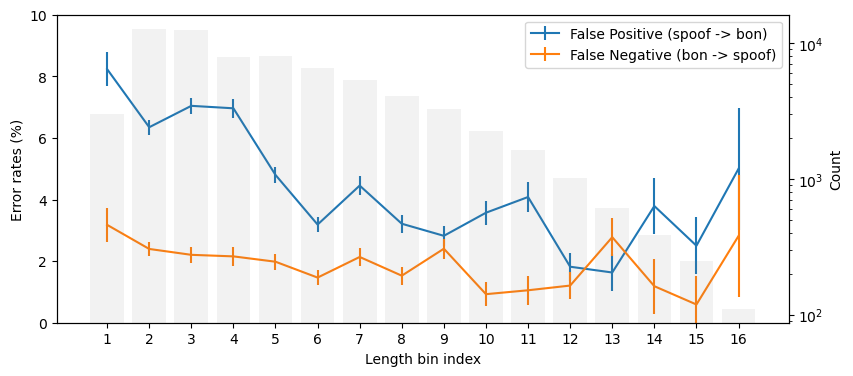

In [72]:
# loss length
error_file = '/gs/bs/tgh-25IAC/ud03523/WORK/project-partialspoof/spoofing-loc-vocoded-aug/project/cp_whisper_hparams_full_x01.yaml/artifacts/outputs/error_multi_x01.pkl'
with open(error_file, 'rb') as file_ptr:
    data = pickle.load(file_ptr)
data = pd.DataFrame(data, columns=['len', 'a', 'b', 'c', 'd'])

lengths = sorted(data['len'].unique())
errors = []

for length in lengths:
    data_= data.query('len == {:d}'.format(length))
    
    a = data_['a'].sum()
    b = data_['b'].sum()
    c = data_['c'].sum()
    d = data_['d'].sum()
    total = a + b + c + d
    accuracy = (a + b) / total if total > 0 else 0
    false_positive_rate = d / (d + b) if (d + b) > 0 else 0
    false_negative_rate = c / (a + c) if (a + c) > 0 else 0
    
    if false_positive_rate > 0 and false_negative_rate > 0:
        sigma = get_conf_inter(false_positive_rate, false_negative_rate, d+b, a+c)
    else:
        sigma = 0
        
    if total > 100:
        errors.append([length, accuracy, false_positive_rate, false_negative_rate, sigma, total])
        
errors = np.array(errors)


fig = plt.figure(figsize=(9.44, 4))
axis = fig.add_subplot(111)
axis.errorbar(np.arange(errors.shape[0]), errors[:, 2] * 100, yerr=errors[:, -2]*100)
axis.errorbar(np.arange(errors.shape[0]), errors[:, 3] * 100, yerr=errors[:, -2]*100)
#axis.errorbar(np.arange(errors.shape[0]), errors[:, -1] * 100)
axis.set_xticks(np.arange(errors.shape[0]))
axis.set_xticklabels(['{:d}'.format(int(x)) for x in errors[:, 0]])
axis.set_xlabel('Length bin index')
axis.set_ylabel('Error rates (%)')
axis.set_ylim([0, 10])
axis.legend(['False Positive (spoof -> bon)', 'False Negative (bon -> spoof)'])
axis2 = axis.twinx()
axis2.bar(np.arange(errors.shape[0]), errors[:, -1], alpha=0.1, facecolor='grey')
axis2.set_ylabel('Count')
axis2.set_yscale('log')